In [1]:
import pandas as pd
import matplotlib.pyplot as plt

results = {"N processos": [], "Méd tempo total": [], "DPP": [], "Speedup": []}

In [2]:
np1 = pd.read_csv("resultadosNP1.csv")
np2 = pd.read_csv("resultadosNP2.csv")
np3 = pd.read_csv("resultadosNP3.csv")
np4 = pd.read_csv("resultadosNP4.csv")

np1 = np1.drop(np1["tempo_total_ms"].idxmax())
np2 = np2.drop(np2["tempo_total_ms"].idxmax())
np3 = np3.drop(np3["tempo_total_ms"].idxmax())
np4 = np4.drop(np4["tempo_total_ms"].idxmax())

for table, np in zip([np1, np2, np3, np4], [1, 2, 3, 4]):
    results["N processos"].append(np)
    results["Méd tempo total"].append(table["tempo_total_ms"].mean())
    results["DPP"].append(table["tempo_total_ms"].std())
    results["Speedup"].append(results["Méd tempo total"][0]/table["tempo_total_ms"].mean())

df_results = pd.DataFrame(results)


In [3]:
df_results

,N processos,Méd tempo total,DPP,Speedup
0,1,1598.468421,34.245909,1.000000
1,2,886.131579,27.335590,1.803873
2,3,704.957895,17.725948,2.267467
3,4,593.700000,12.939474,2.692384


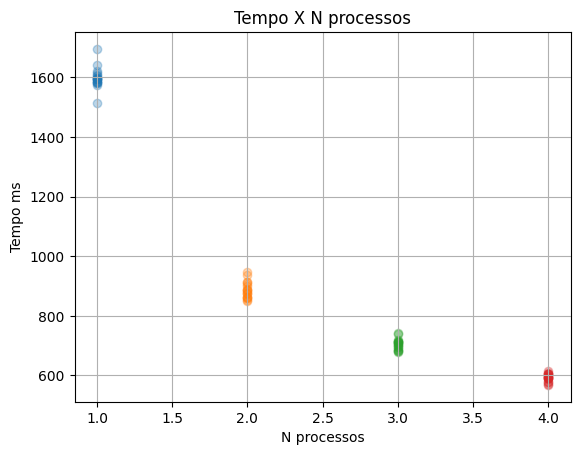

In [4]:
plt.scatter([1]*len(np1.tempo_total_ms), np1.tempo_total_ms, alpha=0.3)
plt.scatter([2]*len(np2.tempo_total_ms), np2.tempo_total_ms, alpha=0.3)
plt.scatter([3]*len(np3.tempo_total_ms), np3.tempo_total_ms, alpha=0.3)
plt.scatter([4]*len(np4.tempo_total_ms), np4.tempo_total_ms, alpha=0.3)
plt.grid(True)
plt.xlabel("N processos")
plt.ylabel("Tempo ms")
plt.title("Tempo X N processos")
plt.show()

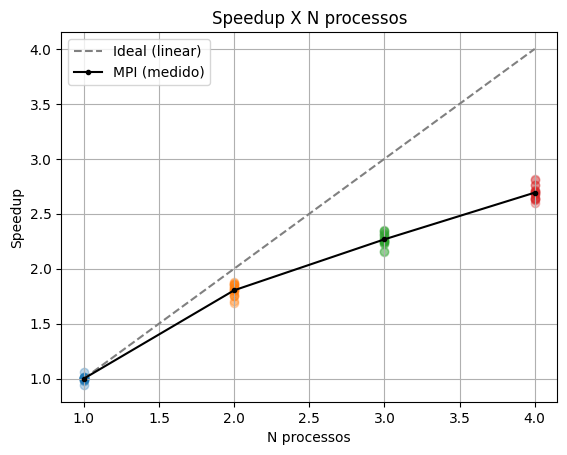

In [19]:
t_serial = float(df_results[df_results["N processos"] == 1]["Méd tempo total"][0])

plt.scatter([1]*len(np1.tempo_total_ms), t_serial/np1.tempo_total_ms, alpha=0.3)
plt.scatter([2]*len(np2.tempo_total_ms), t_serial/np2.tempo_total_ms, alpha=0.3) 
plt.scatter([3]*len(np3.tempo_total_ms), t_serial/np3.tempo_total_ms, alpha=0.3)
plt.scatter([4]*len(np4.tempo_total_ms), t_serial/np4.tempo_total_ms, alpha=0.3)
plt.plot([1, 4], [1, 4], '--', color="gray", label="Ideal (linear)")
plt.plot(df_results["N processos"], df_results["Speedup"], color="black", label="MPI (medido)", marker=".")
plt.grid(True)
plt.xlabel("N processos")
plt.ylabel("Speedup")
plt.title("Speedup X N processos")
plt.legend()
plt.show()